# Explainable Credit Risk Assessment

## 1. Load the Data
- We will bring in the loan applicant data.
- This data has details like income, age, and loan amount.
- It also tells us who repaid and who defaulted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# !nvidia-smi

Wed Oct  7 16:35:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df['loan_amnt'].min()

np.int64(500)

## 2. Exploratory Data Analysis (EDA)
- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

### Basic info about the data
- Check how many rows and columns we have.
- Check the data type of each column.

In [5]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


### Missing values
- Find out which columns have empty or missing values.
- This tells us where we may need to fix things later.

In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance
- Check how many people defaulted vs how many repaid.
- This tells us if our data is balanced or imbalanced.

In [7]:
df.head()
df['loan_status'].unique()

df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

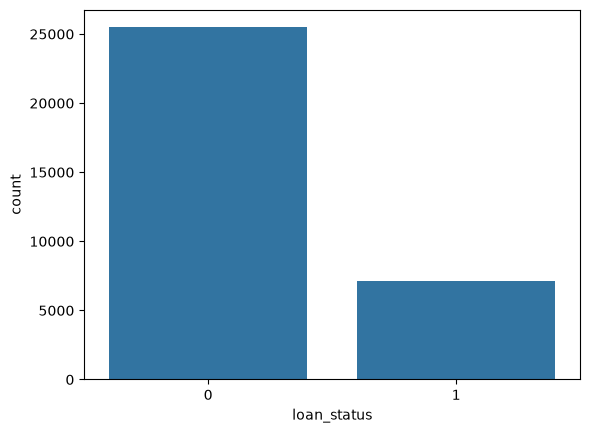

In [8]:
sns.countplot(x='loan_status', data=df)

### Outlier check
- Look for values that seem impossible, like age 144.
- These are signs of bad data entries.

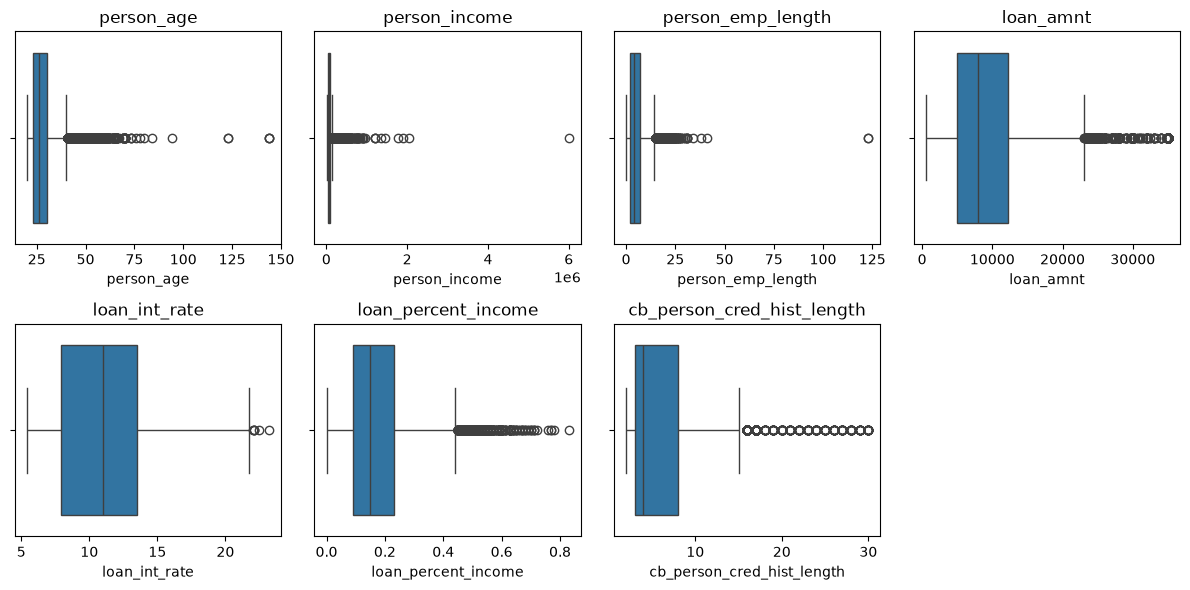

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols = numerical_cols.drop('loan_status')

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
(df['person_age'] > 100).sum()

np.int64(5)

In [11]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Correlation check
- See how strongly features are related to each other.
- This helps us spot repeated or linked information.

<Axes: >

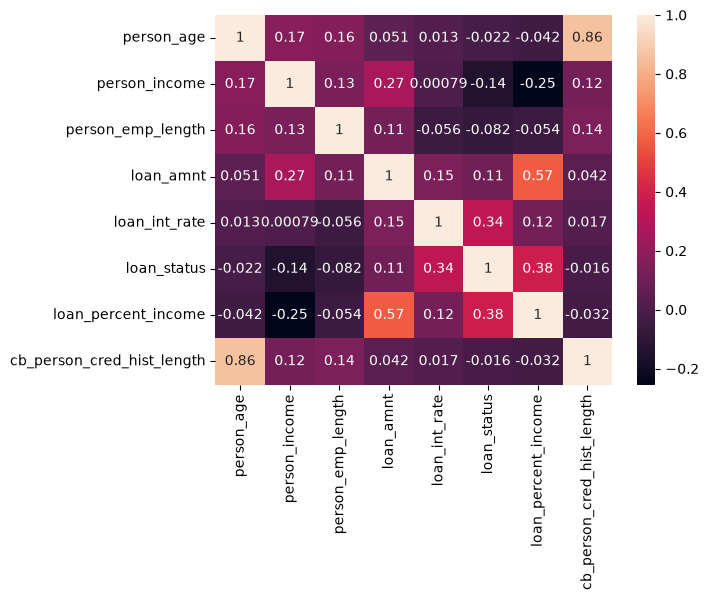

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

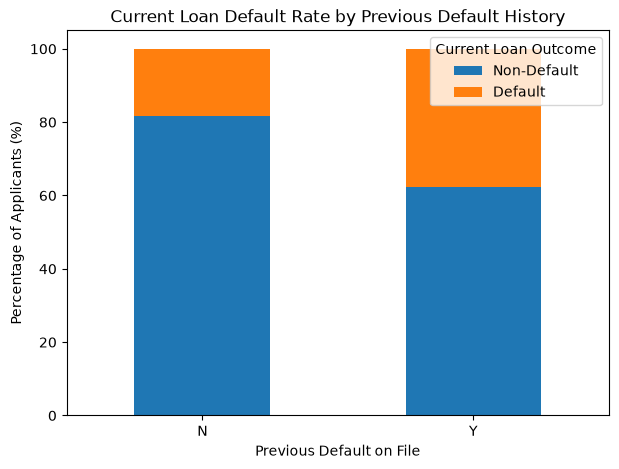

In [14]:
df_plot = (
    df.groupby(['cb_person_default_on_file', 'loan_status'])
      .size()
      .unstack(fill_value=0)
)

df_plot.columns = ['Non-Default', 'Default']

df_pct = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

df_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(7, 5)
)

plt.ylabel('Percentage of Applicants (%)')
plt.xlabel('Previous Default on File')
plt.title('Current Loan Default Rate by Previous Default History')
plt.xticks(rotation=0)
plt.legend(title='Current Loan Outcome')
plt.show()

## 3. Data Validation & Outlier Handling
- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.
- We check if the interest rate looks realistic.
- We also flag rows where numbers don't add up correctly.

In [15]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or above 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)


## 4. Features, Target & Train-Test Split
- We separate the data into input features and the target.
- The target is whether the applicant defaulted or not.
- We split the data into a training part and a testing part.
- The model learns from the training part only.

In [16]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [17]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance
- Very few people actually default in this data.
- If we ignore this, the model may just favor the majority class.
- We give more importance to the minority class during training.
- This helps the model actually learn to spot defaulters.

In [19]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_dev)
scale_weigths = neg/pos

In [20]:
scale_weigths

np.float64(3.6312213039485766)

## 6. Data Preprocessing — Pipelines & Column Transformer
- Raw data is not ready for a model directly.
- We need to prepare numeric and text columns differently.
- We will build a Pipeline for each model.
- We will use ColumnTransformer to apply different steps to different columns.

### Preprocessing for Logistic Regression
- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [21]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), ## Because numerical financial variables often contain outliers and skewed
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


### Preprocessing for XGBoost
- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [22]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


## 7. Evaluation Helper Function
- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [23]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

## 8. Stratified Cross-Validation
- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5,
                        shuffle=True,
                        random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [25]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [26]:
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weigths,
    random_state=42,
    tree_method="hist",
    device="cuda",
    n_jobs=1
))
])

In [27]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_dev , y_dev, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9470945968526715
Accuracy : 0.917952083139717
Precision : 0.8190795992296656
Recall : 0.7963269054178144
F1 : 0.8073360762846882



## 9. Baseline Model — Logistic Regression
- We start with a simple model first.
- This becomes our benchmark to beat.
- We train it and check its score on the test data.

In [28]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_dev, y_dev)

d:\miniconda\envs\env2\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



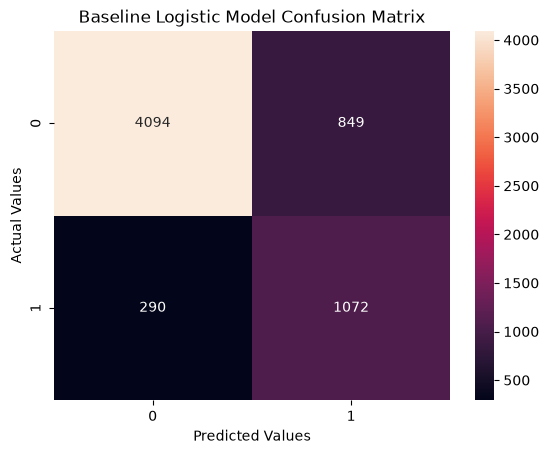

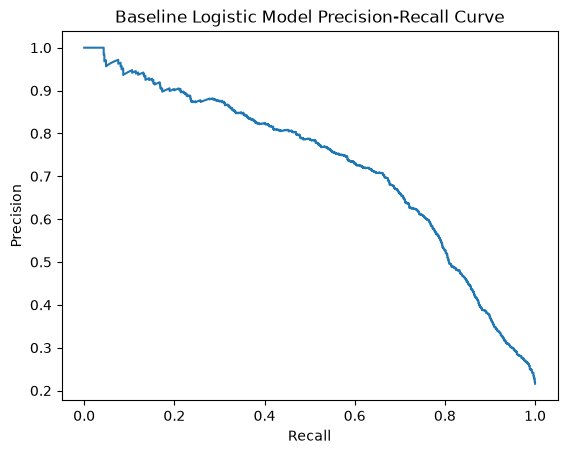

In [29]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

## 10. XGBoost Hyperparameter Tuning
- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [30]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_dev, y_dev)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


param_grid = {
    "classifier__n_estimators": randint(150, 400),
    "classifier__max_depth": randint(3, 8),
    "classifier__learning_rate": uniform(0.02, 0.28),
    "classifier__subsample": uniform(0.7, 0.3),
    "classifier__colsample_bytree": uniform(0.7, 0.3),
    "classifier__min_child_weight": randint(1, 8),
    "classifier__gamma": uniform(0, 3)
}

# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [33]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=35,
    cv=cv,
    scoring="average_precision",
    n_jobs=1,
    verbose=2
)

random_search.fit(X_dev, y_dev)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV] END classifier__colsample_bytree=0.7295102046390154, classifier__gamma=0.36253350842621845, classifier__learning_rate=0.1723659651877021, classifier__max_depth=3, classifier__min_child_weight=7, classifier__n_estimators=157, classifier__subsample=0.7494983799909231; total time=   0.3s
[CV] END classifier__colsample_bytree=0.7295102046390154, classifier__gamma=0.36253350842621845, classifier__learning_rate=0.1723659651877021, classifier__max_depth=3, classifier__min_child_weight=7, classifier__n_estimators=157, classifier__subsample=0.7494983799909231; total time=   0.2s
[CV] END classifier__colsample_bytree=0.7295102046390154, classifier__gamma=0.36253350842621845, classifier__learning_rate=0.1723659651877021, classifier__max_depth=3, classifier__min_child_weight=7, classifier__n_estimators=157, classifier__subsample=0.7494983799909231; total time=   0.2s
[CV] END classifier__colsample_bytree=0.7295102046390154, classif

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DF415B5A90>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DF41508EC0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001DF415B5F90>},
                   scoring='average_precision', verbose=2)

In [34]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [35]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.718122137950226),
 'classifier__gamma': np.float64(0.19292072768738622),
 'classifier__learning_rate': np.float64(0.18671650242840662),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 2,
 'classifier__n_estimators': 247,
 'classifier__subsample': np.float64(0.9748701394737043)}

## 11. Compare Both Models Side by Side
- We now compare Logistic Regression and XGBoost.
- We look at their scores together in one table.
- This helps us pick the better performing model.

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



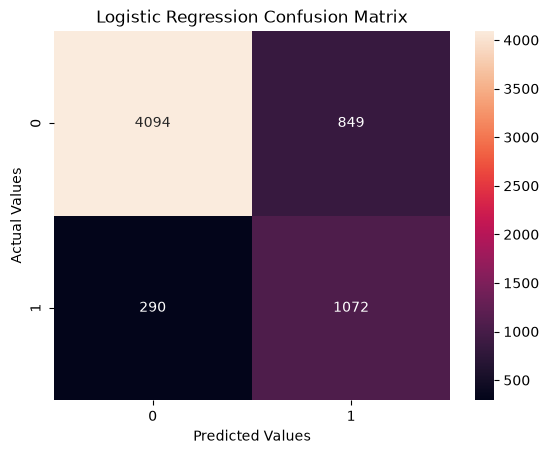

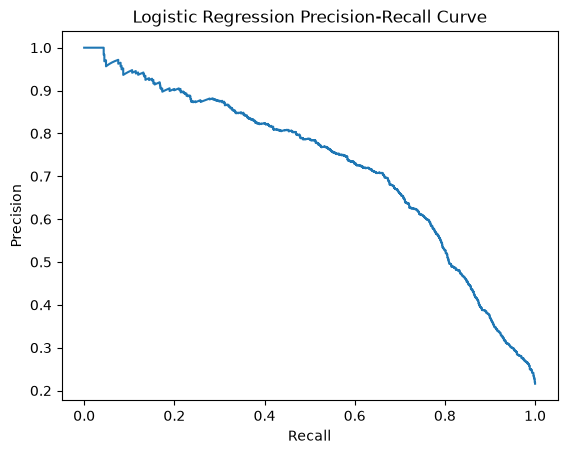

In [37]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.81
Recall : 0.80
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.81      0.80      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



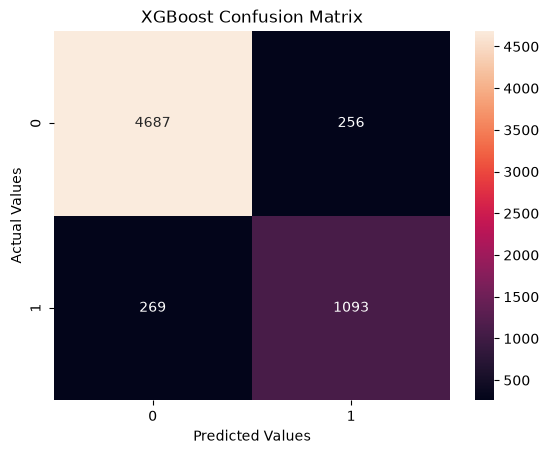

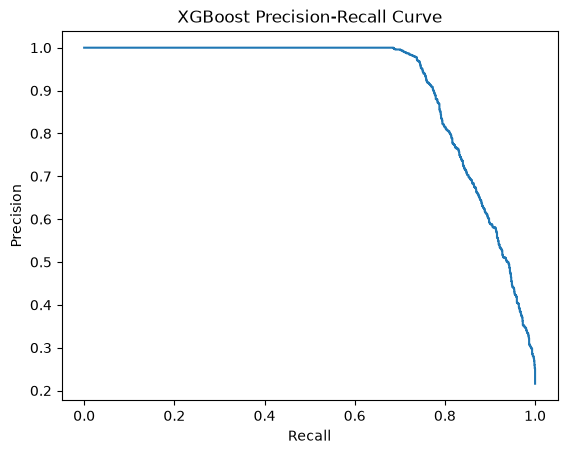

In [38]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("XGBoost", random_search, X_test, y_test)

## 12. Probability Calibration
- Sometimes a model's probability doesn't mean what it says.
- For example, 30% risk should truly mean a 30% chance.
- We check this with a calibration plot.
- We fix it if the probabilities are off.

>
  Methods by which we can fix the poorly calibrated model.
  1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
  2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
  3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature


In [39]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_dev, y_dev)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.18671650242840662),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=2,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=247,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [40]:
# Optimize classification threshold using development data

dev_prob = calibrated_model.predict_proba(X_dev)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_dev,
    dev_prob
)

# F1 is defined for each threshold
f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-9)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 on Development Data: {best_f1:.4f}")

Best Threshold: 0.3470
Best F1 on Development Data: 0.9210


In [41]:
#2. Get probabilites
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [42]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [43]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

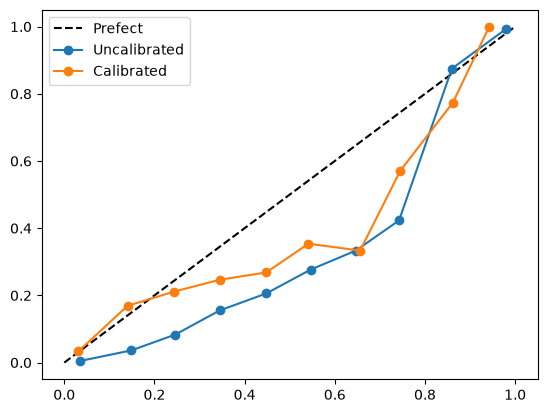

In [44]:
#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [45]:
# Final evaluation on the untouched test set

test_prob = calibrated_model.predict_proba(X_test)[:, 1]

y_pred = (test_prob >= best_threshold).astype(int)

print("Final Test Performance")
print("----------------------")
print(classification_report(y_test, y_pred))

Final Test Performance
----------------------
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.85      0.80      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



In [46]:
from sklearn.metrics import roc_auc_score, brier_score_loss

test_roc_auc = roc_auc_score(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)

print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"Brier Score: {test_brier:.4f}")
print(f"Threshold: {best_threshold:.4f}")

ROC-AUC: 0.9529
Brier Score: 0.0519
Threshold: 0.3470


## 13. Optimizing the Classification Threshold
- The model gives a probability, not a direct yes or no.
- We decide a cut-off point to turn it into a decision.
- We check different cut-off points and pick the best one.

In [47]:
from sklearn.metrics import precision_recall_curve

# Get probabilities from the development data
dev_prob = calibrated_model.predict_proba(X_dev)[:, 1]

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(
    y_dev,
    dev_prob
)

# Calculate F1 score for each threshold
f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-9)
)

# Find threshold giving the highest F1
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 on Development Data: {best_f1:.4f}")

Best Threshold: 0.3470
Best F1 on Development Data: 0.9210


## 14. SHAP Interpretation — Global & Local
- SHAP helps us understand why the model makes a decision.
- It is a way of explaining a "black box" model.

In [48]:
# !pip install shap

In [49]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [50]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [51]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [52]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [53]:
import shap

#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

d:\miniconda\envs\env2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

### Global explanation
- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

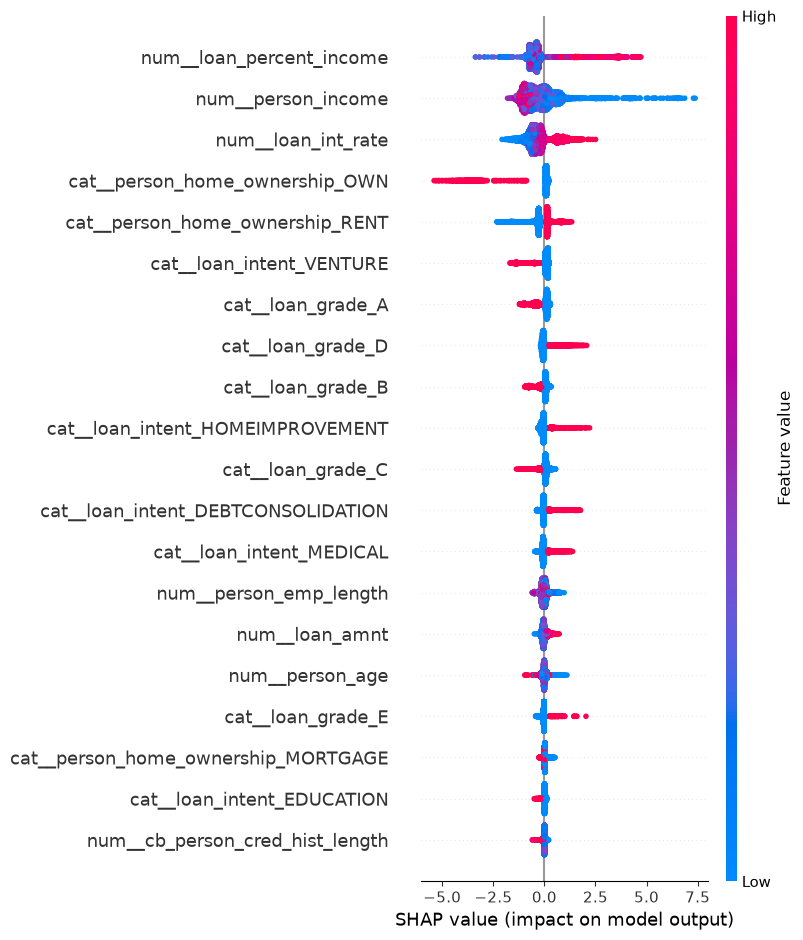

In [55]:
shap.summary_plot(shap_values, X_test_df)

> Loan_percent_income is the strongest
High loan-to-income ratio tends to increase predicted default risk.
blue points are more concentrated toward ## SHAP Summary — XGBoost Credit Risk Model

The SHAP summary plot explains how different features influence the model's prediction of **loan default risk**.

### Key Findings

- **Loan-to-Income Ratio (`loan_percent_income`)**
  - Most influential feature in the model.
  - Higher loan-to-income ratios push predictions toward **default**.
  - Lower ratios generally push predictions toward **non-default**.

- **Person Income (`person_income`)**
  - Higher income generally reduces predicted default risk.
  - Lower income tends to increase predicted default risk.

- **Loan Interest Rate (`loan_int_rate`)**
  - Higher interest rates generally push predictions toward **default**.
  - Lower interest rates tend to reduce predicted risk.

- **Home Ownership**
  - `OWN` is generally associated with **lower predicted default risk**.
  - `RENT` is generally associated with **higher predicted default risk**.

- **Loan Grade**
  - Better grades, particularly **Grade A**, generally push predictions toward lower default risk.
  - Lower grades such as **Grade D and E** tend to increase predicted default risk.

- **Loan Intent**
  - `MEDICAL` and `DEBTCONSOLIDATION` tend to push predictions toward higher default risk.
  - `VENTURE` tends to push predictions toward lower default risk in this model.

- **Less Influential Features**
  - `person_emp_length`
  - `loan_amnt`
  - `person_age`
  - `cb_person_cred_hist_length`

  These features have SHAP values concentrated close to zero, indicating relatively smaller contributions to the model's predictions.

### Overall Interpretation

> The model primarily relies on the borrower's **loan burden relative to income, income level, and loan interest rate** when predicting credit risk. Higher loan-to-income ratios, lower income, and higher interest rates are generally associated with higher predicted default risk.

### Important Note

SHAP explains **how the trained model makes its predictions**, not causal relationships. For example, the association between renting and higher predicted default risk does not mean that renting **causes** default.

Positive SHAP values push the model toward predicting **default**, while negative SHAP values push the model toward predicting **non-default**.the left:
Low loan-to-income ratio tends to decrease predicted default risk.

### Local explanation
- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

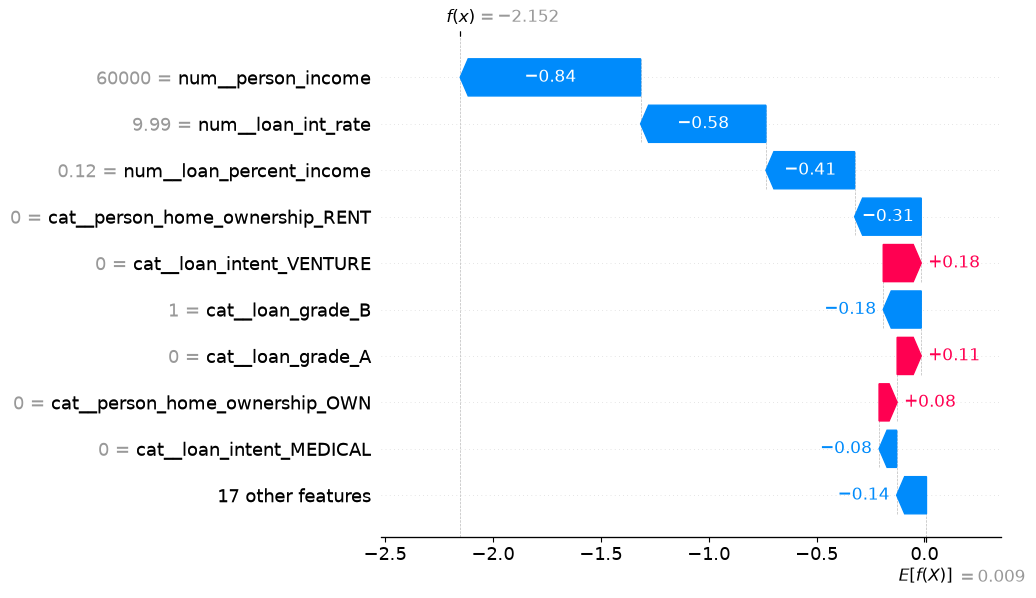

In [56]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positives & False Negatives
- The model will not be perfect.
- False positives are safe people wrongly marked risky.
- False negatives are risky people wrongly marked safe.
- We study these cases to understand where the model struggles.

In [57]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [58]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [59]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [60]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 256
False Negative : 269


In [61]:
#False Negative > False Positive

## 16. Save the Final Model
- Once we are happy with the model, we save it.
- We also save the settings it needs, like the chosen threshold.
- This saved file can now be used in a real application.

In [62]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [63]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']

In [65]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

# Test the exact saved file
test_model = joblib.load("credit_risk_model.pkl")

print("Model saved and reloaded successfully!")

Model saved and reloaded successfully!


In [69]:
joblib.dump(best_model,"xgb_base_model.pkl")

['xgb_base_model.pkl']

In [66]:
import joblib
test_model = joblib.load("credit_risk_model.pkl")

print("Model saved and reloaded successfully!")

Model saved and reloaded successfully!


In [68]:
import joblib
import numpy as np

# 1. Load the exact saved model
test_model = joblib.load("credit_risk_model.pkl")

# 2. Load the saved threshold
threshold = joblib.load("best_threshold.pkl")

print("Model loaded successfully.")
print(f"Threshold: {threshold:.4f}")

# 3. Generate probabilities on the untouched test set
test_prob = test_model.predict_proba(X_test)[:, 1]

# 4. Apply the saved decision threshold
test_pred = (test_prob >= threshold).astype(int)

# 5. Show some predictions
for i in range(10):
    print(
        f"Customer {i+1}: "
        f"PD = {test_prob[i]:.4f} | "
        f"Prediction = {test_pred[i]}"
    )

Model loaded successfully.
Threshold: 0.3470
Customer 1: PD = 0.5487 | Prediction = 1
Customer 2: PD = 0.0244 | Prediction = 0
Customer 3: PD = 0.9443 | Prediction = 1
Customer 4: PD = 0.0240 | Prediction = 0
Customer 5: PD = 0.0514 | Prediction = 0
Customer 6: PD = 0.0250 | Prediction = 0
Customer 7: PD = 0.0150 | Prediction = 0
Customer 8: PD = 0.0147 | Prediction = 0
Customer 9: PD = 0.1295 | Prediction = 0
Customer 10: PD = 0.0278 | Prediction = 0
